# V15 Example: GNN with Multiple Sectors per Ticker

This notebook extends the V15 dense GCN design so that each ticker may belong to several sectors.

Instead of a single one-hot sector feature such as

```python
{"NVDA": "Semiconductors"}
```

we use weighted memberships:

```python
{"NVDA": {"Semiconductors": 6, "AI Infrastructure": 3, "Networking": 1}}
```

The supplied numbers do **not** need to sum to 1. They are normalized independently for every ticker:

\[
\hat w_{i,s}=\frac{\max(w_{i,s},0)}{\sum_k \max(w_{i,k},0)}
\]

Therefore, every valid ticker has:

\[
\sum_s \hat w_{i,s}=1
\]

This prevents a ticker with several sector labels from producing a sector-feature factor greater than 1.

## 1. Imports and reproducibility

The example uses only `numpy`, `pandas`, `networkx`, `matplotlib`, and `torch`. It does not require PyTorch Geometric.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Mapping, Sequence

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
from torch import nn

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.13.0+cu130
CUDA available: True


## 2. Raw multi-sector input

The weights below intentionally use different scales and several rows sum to more than 1. The normalization function makes them comparable.

In [2]:
RAW_SECTOR_WEIGHTS = {
    "NVDA": {
        "Semiconductors": 0.50,
        "AI": 0.30,
        "DataCenter": 0.20,
    },

    "AMD": {
        "Semiconductors": 0.55,
        "AI": 0.25,
        "DataCenter": 0.20,
    },

    "AVGO": {
        "Semiconductors": 0.40,
        "Networking": 0.35,
        "AI": 0.25,
    },

    "MRVL": {
        "Semiconductors": 0.40,
        "Networking": 0.35,
        "AI": 0.25,
    },

    "ANET": {
        "Networking": 0.60,
        "AI": 0.25,
        "DataCenter": 0.15,
    },

    "BNT": {
        "QuantumComputing": 0.75,
        "AI": 0.25,
    },

    "CBRS": {
        "Semiconductors": 0.45,
        "AI": 0.35,
        "Cloud": 0.20,
    },

    "LITE": {
        "Networking": 0.55,
        "Photonics": 0.45,
    },

    "LRCX": {
        "Equipment": 0.70,
        "Semiconductors": 0.30,
    },

    "KLAC": {
        "Equipment": 0.75,
        "Semiconductors": 0.25,
    },

    "AMAT": {
        "Equipment": 0.60,
        "Semiconductors": 0.25,
        "Display": 0.15,
    },

    "MU": {
        "Memory": 0.70,
        "Semiconductors": 0.30,
    },

    "INTC": {
        "Semiconductors": 0.55,
        "AI": 0.15,
        "Foundry": 0.30,
    },

    "AAPL": {
        "Technology": 0.45,
        "ConsumerElectronics": 0.35,
        "Services": 0.20,
    },

    "QNT": {
        "QuantumComputing": 0.70,
        "AI": 0.30,
    },

    "QBTS": {
        "QuantumComputing": 0.75,
        "AI": 0.25,
    },

    "SPCX": {
        "Space": 0.70,
        "Defense": 0.30,
    },

    "META": {
        "Internet": 0.45,
        "AI": 0.35,
        "Advertising": 0.20,
    },

    "IONQ": {
        "QuantumComputing": 0.80,
        "AI": 0.20,
    },
}

## 3. Normalize each ticker independently

Rules:

- Negative values are rejected by default.
- Missing or zero-total memberships fall back to `Other: 1.0`.
- The result for each ticker sums to 1 within numerical tolerance.
- An optional `top_k` can retain only the largest memberships before re-normalizing.

In [4]:
def normalize_sector_weights(
    raw: Mapping[str, Mapping[str, float] | str],
    *,
    top_k: int | None = None,
    reject_negative: bool = True,
    fallback_sector: str = "Other",
) -> dict[str, dict[str, float]]:
    """Normalize sector memberships separately for every ticker."""
    normalized: dict[str, dict[str, float]] = {}

    for ticker_raw, memberships_raw in raw.items():
        ticker = str(ticker_raw).strip().upper()
        if not ticker:
            raise ValueError("Ticker names must be non-empty")

        # Backward compatibility: {"MU": "Memory"}
        if isinstance(memberships_raw, str):
            memberships = {memberships_raw.strip(): 1.0}
        else:
            memberships = {
                str(sector).strip(): float(weight)
                for sector, weight in memberships_raw.items()
                if str(sector).strip()
            }

        if reject_negative and any(weight < 0 for weight in memberships.values()):
            bad = {s: w for s, w in memberships.items() if w < 0}
            raise ValueError(f"{ticker} has negative sector weights: {bad}")

        # If negatives are allowed, clip them to zero.
        memberships = {s: max(0.0, w) for s, w in memberships.items()}

        if top_k is not None:
            if top_k < 1:
                raise ValueError("top_k must be at least 1")
            memberships = dict(
                sorted(memberships.items(), key=lambda item: item[1], reverse=True)[:top_k]
            )

        total = float(sum(memberships.values()))
        if not np.isfinite(total) or total <= 0:
            normalized[ticker] = {fallback_sector: 1.0}
        else:
            normalized[ticker] = {
                sector: weight / total
                for sector, weight in memberships.items()
                if weight > 0
            }

    return normalized


def validate_normalized_weights(
    memberships: Mapping[str, Mapping[str, float]],
    atol: float = 1e-8,
) -> pd.DataFrame:
    rows = []
    for ticker, weights in memberships.items():
        total = float(sum(weights.values()))
        rows.append({
            "ticker": ticker,
            "sector_count": len(weights),
            "weight_sum": total,
            "minimum_weight": min(weights.values()),
            "valid": bool(np.isclose(total, 1.0, atol=atol) and min(weights.values()) >= 0),
        })
    return pd.DataFrame(rows).set_index("ticker").sort_index()

SECTOR_WEIGHTS = normalize_sector_weights(RAW_SECTOR_WEIGHTS)
validation = validate_normalized_weights(SECTOR_WEIGHTS)
validation

,sector_count,weight_sum,minimum_weight,valid
ticker,,,,
AAPL,3,1.0,0.20,True
AMAT,3,1.0,0.15,True
AMD,3,1.0,0.20,True
ANET,3,1.0,0.15,True
AVGO,3,1.0,0.25,True
BNT,2,1.0,0.25,True
CBRS,3,1.0,0.20,True
INTC,3,1.0,0.15,True
IONQ,2,1.0,0.20,True


In [5]:
sector_weight_table = (
    pd.DataFrame(SECTOR_WEIGHTS)
    .T
    .fillna(0.0)
    .sort_index()
)

assert validation["valid"].all()
assert np.allclose(sector_weight_table.sum(axis=1).to_numpy(), 1.0)

sector_weight_table.round(3)

,Semiconductors,AI,DataCenter,Networking,QuantumComputing,Cloud,Photonics,Equipment,Display,Memory,Foundry,Technology,ConsumerElectronics,Services,Space,Defense,Internet,Advertising
AAPL,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.45,0.35,0.2,0.0,0.0,0.00,0.0
AMAT,0.25,0.00,0.00,0.00,0.00,0.0,0.00,0.60,0.15,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.00,0.0
AMD,0.55,0.25,0.20,0.00,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.00,0.0
ANET,0.00,0.25,0.15,0.60,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.00,0.0
AVGO,0.40,0.25,0.00,0.35,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.00,0.0
BNT,0.00,0.25,0.00,0.00,0.75,0.0,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.00,0.0
CBRS,0.45,0.35,0.00,0.00,0.00,0.2,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.00,0.0
INTC,0.55,0.15,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.0,0.3,0.00,0.00,0.0,0.0,0.0,0.00,0.0
IONQ,0.00,0.20,0.00,0.00,0.80,0.0,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.00,0.0
KLAC,0.25,0.00,0.00,0.00,0.00,0.0,0.00,0.75,0.00,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.00,0.0


## 4. Visual check of normalized memberships

Every horizontal row represents one ticker. Its stacked sector weights sum to exactly 1.

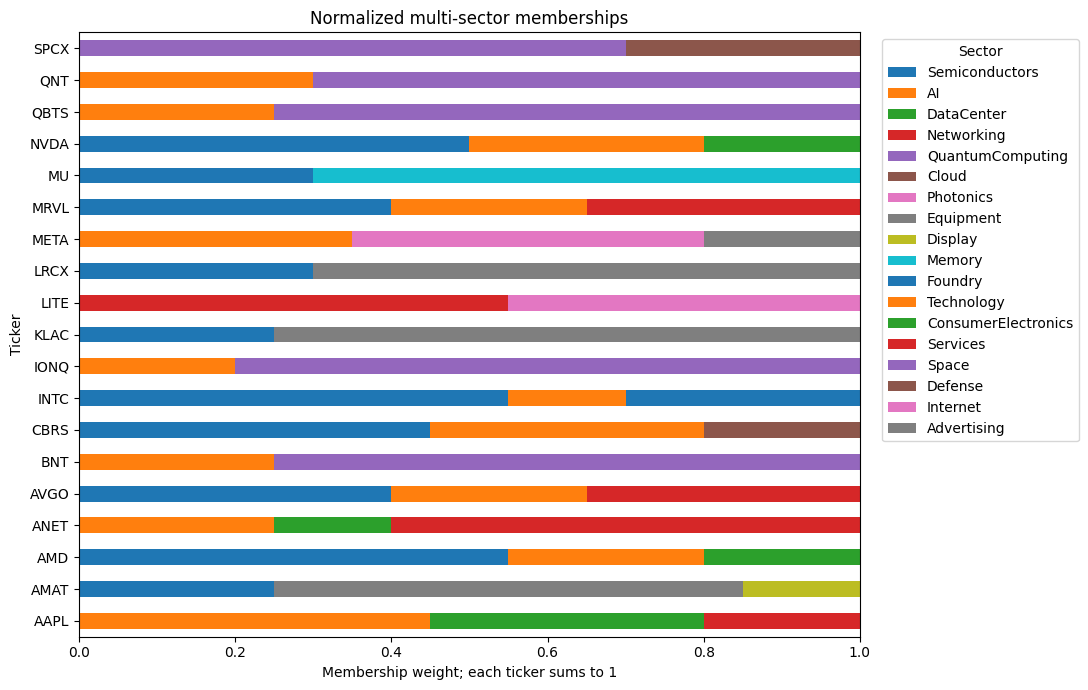

In [6]:
ax = sector_weight_table.plot(kind="barh", stacked=True, figsize=(11, 7))
ax.set_title("Normalized multi-sector memberships")
ax.set_xlabel("Membership weight; each ticker sums to 1")
ax.set_ylabel("Ticker")
ax.legend(title="Sector", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 5. Generate synthetic V15-style graph snapshots

This demonstration creates a chronological sequence of ticker networks. Nodes contain V15-like numerical attributes, and edges contain correlation-like weights.

The target has three market regimes:

- `0`: calm
- `1`: sector rotation
- `2`: market stress

The synthetic data is only for testing the multi-sector GNN mechanism. Replace these snapshots and labels with V15's actual `aligned_frames` and HMM regimes in production.

In [7]:
TICKERS = list(SECTOR_WEIGHTS)
N_SNAPSHOTS = 72
REGIME_NAMES = {0: "Calm", 1: "Sector rotation", 2: "Market stress"}


def shared_sector_similarity(ticker_a: str, ticker_b: str) -> float:
    wa = SECTOR_WEIGHTS[ticker_a]
    wb = SECTOR_WEIGHTS[ticker_b]
    sectors = set(wa) | set(wb)
    return float(sum(min(wa.get(s, 0.0), wb.get(s, 0.0)) for s in sectors))


def make_synthetic_snapshot(t: int, rng: np.random.Generator) -> tuple[nx.Graph, int]:
    # Chronological regime blocks with repeated transitions.
    phase = t % 24
    regime = 0 if phase < 9 else (1 if phase < 17 else 2)

    G = nx.Graph(snapshot=t, regime=regime)

    for ticker in TICKERS:
        ai_weight = SECTOR_WEIGHTS[ticker].get("AI Infrastructure", 0.0)
        quantum_weight = SECTOR_WEIGHTS[ticker].get("Quantum Computing", 0.0)

        base_vol = [0.012, 0.022, 0.045][regime]
        volatility = base_vol * (1 + 0.8 * quantum_weight) + rng.normal(0, 0.0015)
        momentum = [0.010, 0.003, -0.025][regime] + 0.018 * ai_weight + rng.normal(0, 0.008)
        capital_share = max(0.001, rng.lognormal(mean=-2.4 + 0.15 * ai_weight, sigma=0.35))
        node_curvature = [0.20, 0.02, -0.22][regime] + rng.normal(0, 0.05)

        G.add_node(
            ticker,
            degree_proxy=0.0,  # replaced after edges are built
            capital_share=capital_share,
            ricciCurvature=node_curvature,
            momentum=momentum,
            volatility=max(volatility, 0.001),
            volume_change=rng.normal([0.02, 0.10, 0.28][regime], 0.08),
        )

    for i, u in enumerate(TICKERS):
        for v in TICKERS[i + 1:]:
            overlap = shared_sector_similarity(u, v)
            market_component = [0.10, 0.24, 0.52][regime]
            corr = market_component + 0.50 * overlap + rng.normal(0, 0.08)
            corr = float(np.clip(corr, -0.20, 0.95))

            # Sparse in calm periods; denser under stress.
            threshold = [0.42, 0.38, 0.32][regime]
            if corr > threshold:
                G.add_edge(
                    u,
                    v,
                    correlation=corr,
                    distance=float(np.sqrt(max(0.0, 2.0 * (1.0 - corr)))),
                    ricciCurvature=float([0.14, 0.00, -0.18][regime] + rng.normal(0, 0.06)),
                )

    for ticker in G.nodes:
        G.nodes[ticker]["degree_proxy"] = float(G.degree(ticker))

    return G, regime

rng = np.random.default_rng(SEED)
created = [make_synthetic_snapshot(t, rng) for t in range(N_SNAPSHOTS)]
graphs = [item[0] for item in created]
labels = np.array([item[1] for item in created], dtype=np.int64)

print("Snapshots:", len(graphs))
print("Regime counts:", pd.Series(labels).map(REGIME_NAMES).value_counts().to_dict())
print("First graph:", graphs[0])

Snapshots: 72
Regime counts: {'Calm': 27, 'Sector rotation': 24, 'Market stress': 21}
First graph: Graph with 19 nodes and 21 edges


## 6. Convert a graph to dense GCN tensors

Each node receives six numerical V15-style features plus one feature per sector.

For a ticker belonging to several sectors, its sector part is a **weighted multi-hot vector**. Because each row is normalized, the sector-feature sum is 1 rather than the number of sectors.

In [8]:
NUMERIC_FEATURES = (
    "degree_proxy",
    "capital_share",
    "ricciCurvature",
    "momentum",
    "volatility",
    "volume_change",
)


def build_sector_vocabulary(
    memberships: Mapping[str, Mapping[str, float]],
) -> dict[str, int]:
    names = sorted({sector for weights in memberships.values() for sector in weights})
    return {sector: i for i, sector in enumerate(names)}


def graph_to_dense_multisector(
    G: nx.Graph,
    nodes: Sequence[str],
    sector_weights: Mapping[str, Mapping[str, float]],
    sector_vocab: Mapping[str, int],
) -> tuple[torch.Tensor, torch.Tensor]:
    node_index = {node: i for i, node in enumerate(nodes)}
    n_nodes = len(nodes)
    n_features = len(NUMERIC_FEATURES) + len(sector_vocab)

    adjacency = np.zeros((n_nodes, n_nodes), dtype=np.float32)
    features = np.zeros((n_nodes, n_features), dtype=np.float32)

    for node, i in node_index.items():
        if node not in G:
            continue

        attrs = G.nodes[node]
        features[i, :len(NUMERIC_FEATURES)] = [
            float(attrs.get(name, 0.0)) for name in NUMERIC_FEATURES
        ]

        memberships = sector_weights.get(str(node).upper(), {"Other": 1.0})
        for sector, weight in memberships.items():
            if sector in sector_vocab:
                features[i, len(NUMERIC_FEATURES) + sector_vocab[sector]] = float(weight)

    for u, v, attrs in G.edges(data=True):
        if u in node_index and v in node_index:
            weight = abs(float(attrs.get("correlation", 1.0)))
            adjacency[node_index[u], node_index[v]] = weight
            adjacency[node_index[v], node_index[u]] = weight

    # Add self-loops and symmetric GCN normalization: D^(-1/2) A D^(-1/2)
    adjacency += np.eye(n_nodes, dtype=np.float32)
    degree = np.maximum(adjacency.sum(axis=1), 1e-8)
    inv_sqrt_degree = 1.0 / np.sqrt(degree)
    adjacency = inv_sqrt_degree[:, None] * adjacency * inv_sqrt_degree[None, :]

    return torch.tensor(features), torch.tensor(adjacency)

NODES = sorted(TICKERS)
SECTOR_VOCAB = build_sector_vocabulary(SECTOR_WEIGHTS)
PAIRS = [
    graph_to_dense_multisector(G, NODES, SECTOR_WEIGHTS, SECTOR_VOCAB)
    for G in graphs
]

print("Node feature tensor:", PAIRS[0][0].shape)
print("Normalized adjacency:", PAIRS[0][1].shape)
print("Numeric features:", len(NUMERIC_FEATURES))
print("Sector features:", len(SECTOR_VOCAB))

Node feature tensor: torch.Size([19, 24])
Normalized adjacency: torch.Size([19, 19])
Numeric features: 6
Sector features: 18


In [9]:
feature_names = list(NUMERIC_FEATURES) + [
    sector for sector, _ in sorted(SECTOR_VOCAB.items(), key=lambda item: item[1])
]
first_features = pd.DataFrame(PAIRS[0][0].numpy(), index=NODES, columns=feature_names)

sector_columns = feature_names[len(NUMERIC_FEATURES):]
sector_sums = first_features[sector_columns].sum(axis=1)
assert np.allclose(sector_sums.to_numpy(), 1.0)

first_features.loc[["NVDA", "MRVL", "IONQ"], sector_columns].round(3)

,AI,Advertising,Cloud,ConsumerElectronics,DataCenter,Defense,Display,Equipment,Foundry,Internet,Memory,Networking,Photonics,QuantumComputing,Semiconductors,Services,Space,Technology
NVDA,0.30,0.0,0.0,0.0,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.5,0.0,0.0,0.0
MRVL,0.25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.35,0.0,0.0,0.4,0.0,0.0,0.0
IONQ,0.20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.8,0.0,0.0,0.0,0.0


## 7. Dense graph-level GCN

This follows V15's graph-classification structure:

1. two graph-convolution layers,
2. mean pooling across nodes,
3. one output vector per graph snapshot,
4. chronological 70/30 train/test split,
5. class-weighted cross-entropy.

In [10]:
@dataclass
class GNNResult:
    labels: np.ndarray
    predictions: np.ndarray
    probabilities: np.ndarray
    train_indices: np.ndarray
    test_indices: np.ndarray
    accuracy: float
    balanced_accuracy: float
    losses: list[float]
    device: str
    class_weights: np.ndarray


class DenseGCN(nn.Module):
    def __init__(self, input_features: int, hidden: int, classes: int):
        super().__init__()
        self.layer1 = nn.Linear(input_features, hidden)
        self.layer2 = nn.Linear(hidden, hidden)
        self.output = nn.Linear(hidden, classes)

    def forward(self, x: torch.Tensor, a: torch.Tensor) -> torch.Tensor:
        h = torch.relu(self.layer1(a @ x))
        h = torch.relu(self.layer2(a @ h))
        graph_embedding = h.mean(dim=0)
        return self.output(graph_embedding)


def train_multisector_gcn(
    pairs: Sequence[tuple[torch.Tensor, torch.Tensor]],
    labels: Sequence[int],
    *,
    epochs: int = 160,
    hidden: int = 32,
    learning_rate: float = 0.004,
    random_state: int = 42,
) -> GNNResult:
    torch.manual_seed(random_state)
    np.random.seed(random_state)

    y = np.asarray(labels, dtype=np.int64).reshape(-1)
    if len(pairs) != len(y):
        raise ValueError("Graph/label length mismatch")
    if len(pairs) < 10:
        raise ValueError("At least 10 graph snapshots are required")

    classes = np.unique(y)
    remap = {original: new for new, original in enumerate(classes)}
    y_remapped = np.array([remap[value] for value in y], dtype=np.int64)

    split = max(2, min(len(y) - 2, int(len(y) * 0.70)))
    train_indices = np.arange(split)
    test_indices = np.arange(split, len(y))

    counts = np.bincount(y_remapped[train_indices], minlength=len(classes))
    class_weights = len(train_indices) / (len(classes) * np.maximum(counts, 1))

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = DenseGCN(pairs[0][0].shape[1], hidden, len(classes)).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    loss_function = nn.CrossEntropyLoss(
        weight=torch.tensor(class_weights, dtype=torch.float32, device=device)
    )

    losses: list[float] = []
    model.train()
    for _ in range(int(epochs)):
        optimizer.zero_grad()
        logits = torch.stack([
            model(x.to(device), a.to(device)) for x, a in pairs[:split]
        ])
        target = torch.tensor(y_remapped[:split], dtype=torch.long, device=device)
        loss = loss_function(logits, target)
        loss.backward()
        optimizer.step()
        losses.append(float(loss.detach().cpu()))

    model.eval()
    with torch.no_grad():
        logits = torch.stack([
            model(x.to(device), a.to(device)) for x, a in pairs
        ])
        probabilities = torch.softmax(logits, dim=1).cpu().numpy()
        predicted_remapped = probabilities.argmax(axis=1)

    predictions = np.array([classes[i] for i in predicted_remapped])
    accuracy = float((predictions[test_indices] == y[test_indices]).mean())

    recalls = []
    for cls in np.unique(y[test_indices]):
        mask = y[test_indices] == cls
        recalls.append(float((predictions[test_indices][mask] == cls).mean()))
    balanced_accuracy = float(np.mean(recalls)) if recalls else float("nan")

    return GNNResult(
        labels=y,
        predictions=predictions,
        probabilities=probabilities,
        train_indices=train_indices,
        test_indices=test_indices,
        accuracy=accuracy,
        balanced_accuracy=balanced_accuracy,
        losses=losses,
        device=device,
        class_weights=class_weights,
    )

result = train_multisector_gcn(PAIRS, labels)
print("Device:", result.device)
print("Test accuracy:", round(result.accuracy, 3))
print("Balanced accuracy:", round(result.balanced_accuracy, 3))
print("Class weights:", np.round(result.class_weights, 3))

Device: cuda
Test accuracy: 1.0
Balanced accuracy: 1.0
Class weights: [0.833 1.042 1.19 ]


## 8. GNN input-network plot

This interactive Plotly view shows the **same ticker graph and attributes supplied to the GCN**. Choose any snapshot index. Node color represents the primary sector, node size represents capital share, edge width represents absolute correlation, and edge style separates positive and negative Ricci curvature. Hovering over a node displays all normalized multi-sector weights, whose sum is one for each ticker.


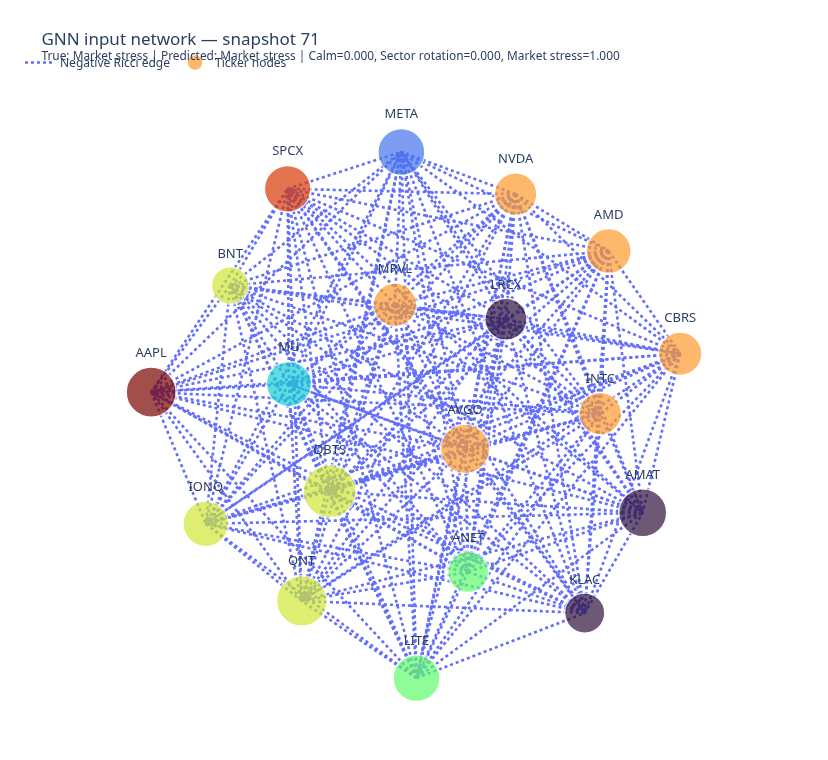

In [11]:
import plotly.graph_objects as go


def primary_sector(ticker: str) -> str:
    weights = SECTOR_WEIGHTS.get(ticker, {"Other": 1.0})
    return max(weights, key=weights.get)


def format_memberships(ticker: str) -> str:
    weights = SECTOR_WEIGHTS.get(ticker, {"Other": 1.0})
    ordered = sorted(weights.items(), key=lambda item: item[1], reverse=True)
    return "<br>".join(f"{sector}: {weight:.3f}" for sector, weight in ordered)


def gnn_network_figure(
    snapshot_index: int,
    *,
    layout_seed: int = 42,
    dimensions: int = 2,
) -> go.Figure:
    """Plot one graph snapshot used by the GCN.

    Parameters
    ----------
    snapshot_index:
        Position in ``graphs`` and ``result``.
    layout_seed:
        Fixed seed keeps positions stable between reruns.
    dimensions:
        Currently 2. Reserved for a future 3-D implementation.
    """
    if dimensions != 2:
        raise ValueError("This example currently supports dimensions=2")
    if not 0 <= snapshot_index < len(graphs):
        raise IndexError(f"snapshot_index must be from 0 to {len(graphs) - 1}")

    G = graphs[snapshot_index]
    pos = nx.spring_layout(G, seed=layout_seed, weight="correlation", iterations=120)

    # Use separate traces so positive and negative Ricci edges are distinguishable.
    edge_groups = {
        "Positive Ricci edge": {"x": [], "y": [], "width": []},
        "Negative Ricci edge": {"x": [], "y": [], "width": []},
    }

    edge_hover_x, edge_hover_y, edge_hover_text = [], [], []
    for u, v, attrs in G.edges(data=True):
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        corr = float(attrs.get("correlation", 0.0))
        ricci = float(attrs.get("ricciCurvature", 0.0))
        group = "Positive Ricci edge" if ricci >= 0 else "Negative Ricci edge"
        edge_groups[group]["x"] += [x0, x1, None]
        edge_groups[group]["y"] += [y0, y1, None]
        edge_groups[group]["width"].append(0.6 + 3.2 * abs(corr))

        # Invisible midpoint markers provide precise edge hover information.
        edge_hover_x.append((x0 + x1) / 2)
        edge_hover_y.append((y0 + y1) / 2)
        edge_hover_text.append(
            f"{u} — {v}<br>Correlation: {corr:.3f}"
            f"<br>Distance: {float(attrs.get('distance', np.nan)):.3f}"
            f"<br>Ricci curvature: {ricci:.3f}"
        )

    fig = go.Figure()
    edge_dash = {"Positive Ricci edge": "solid", "Negative Ricci edge": "dot"}
    for name, values in edge_groups.items():
        if not values["x"]:
            continue
        # Plotly applies one width per line trace. Use the group mean while exact
        # correlation remains visible in the edge hover markers.
        mean_width = float(np.mean(values["width"])) if values["width"] else 1.0
        fig.add_trace(go.Scatter(
            x=values["x"], y=values["y"],
            mode="lines",
            line={"width": mean_width, "dash": edge_dash[name]},
            hoverinfo="skip",
            name=name,
        ))

    fig.add_trace(go.Scatter(
        x=edge_hover_x,
        y=edge_hover_y,
        mode="markers",
        marker={"size": 10, "opacity": 0.0},
        text=edge_hover_text,
        hovertemplate="%{text}<extra></extra>",
        name="Edge details",
        showlegend=False,
    ))

    sectors = sorted({primary_sector(node) for node in G.nodes})
    sector_to_code = {sector: i for i, sector in enumerate(sectors)}

    node_x, node_y, node_text, node_sizes, node_codes, labels_text = [], [], [], [], [], []
    capital_values = np.array([
        float(G.nodes[node].get("capital_share", 0.0)) for node in G.nodes
    ])
    capital_scale = capital_values / max(float(capital_values.max()), 1e-12)

    for node, scaled_capital in zip(G.nodes, capital_scale):
        x, y = pos[node]
        attrs = G.nodes[node]
        sector = primary_sector(node)
        memberships_sum = sum(SECTOR_WEIGHTS.get(node, {"Other": 1.0}).values())

        node_x.append(x)
        node_y.append(y)
        labels_text.append(node)
        node_codes.append(sector_to_code[sector])
        node_sizes.append(18 + 35 * np.sqrt(max(scaled_capital, 0.0)))
        node_text.append(
            f"<b>{node}</b>"
            f"<br>Primary sector: {sector}"
            f"<br><b>Normalized sector features</b><br>{format_memberships(node)}"
            f"<br>Weight sum: {memberships_sum:.6f}"
            f"<br>Degree: {G.degree(node)}"
            f"<br>Capital share: {float(attrs.get('capital_share', 0.0)):.4f}"
            f"<br>Momentum: {float(attrs.get('momentum', 0.0)):.4f}"
            f"<br>Volatility: {float(attrs.get('volatility', 0.0)):.4f}"
            f"<br>Node Ricci: {float(attrs.get('ricciCurvature', 0.0)):.4f}"
        )

    fig.add_trace(go.Scatter(
        x=node_x,
        y=node_y,
        mode="markers+text",
        text=labels_text,
        textposition="top center",
        textfont={"size": 13},
        customdata=node_text,
        hovertemplate="%{customdata}<extra></extra>",
        marker={
            "size": node_sizes,
            "color": node_codes,
            "colorscale": "Turbo",
            "showscale": False,
            "line": {"width": 1.5},
        },
        name="Ticker nodes",
    ))

    true_name = REGIME_NAMES[int(result.labels[snapshot_index])]
    predicted_name = REGIME_NAMES[int(result.predictions[snapshot_index])]
    probabilities = result.probabilities[snapshot_index]
    probability_text = ", ".join(
        f"{REGIME_NAMES[i]}={probability:.3f}"
        for i, probability in enumerate(probabilities)
    )

    fig.update_layout(
        title=(
            f"GNN input network — snapshot {snapshot_index}"
            f"<br><sup>True: {true_name} | Predicted: {predicted_name} | "
            f"{probability_text}</sup>"
        ),
        height=760,
        hovermode="closest",
        margin={"l": 20, "r": 20, "t": 90, "b": 20},
        xaxis={"visible": False},
        yaxis={"visible": False, "scaleanchor": "x", "scaleratio": 1},
        legend={"orientation": "h", "yanchor": "bottom", "y": 1.02},
        template="plotly_white",
    )
    return fig


# Change this index to inspect a calm, rotation, or stress graph.
SELECTED_SNAPSHOT = int(result.test_indices[-1])
gnn_network_figure(SELECTED_SNAPSHOT).show()


## 9. Training and prediction diagnostics

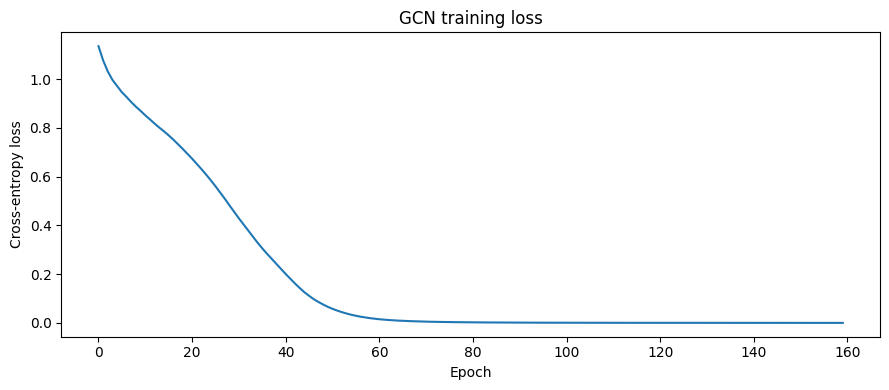

In [12]:
plt.figure(figsize=(9, 4))
plt.plot(result.losses)
plt.title("GCN training loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.tight_layout()
plt.show()

In [13]:
prediction_table = pd.DataFrame({
    "snapshot": np.arange(len(labels)),
    "actual": pd.Series(result.labels).map(REGIME_NAMES),
    "predicted": pd.Series(result.predictions).map(REGIME_NAMES),
    "split": np.where(np.arange(len(labels)) < result.test_indices[0], "train", "test"),
    "confidence": result.probabilities.max(axis=1),
})

prediction_table.tail(22)

,snapshot,actual,predicted,split,confidence
50,50,Calm,Calm,test,0.999794
51,51,Calm,Calm,test,0.999718
52,52,Calm,Calm,test,0.999959
53,53,Calm,Calm,test,0.999316
54,54,Calm,Calm,test,0.999838
55,55,Calm,Calm,test,0.999770
56,56,Calm,Calm,test,0.999788
57,57,Sector rotation,Sector rotation,test,0.999388
58,58,Sector rotation,Sector rotation,test,0.998770
59,59,Sector rotation,Sector rotation,test,0.999215


In [14]:
confusion = pd.crosstab(
    prediction_table.loc[result.test_indices, "actual"],
    prediction_table.loc[result.test_indices, "predicted"],
    rownames=["Actual"],
    colnames=["Predicted"],
    dropna=False,
)
confusion

Predicted,Calm,Market stress,Sector rotation
Actual,,,
Calm,7,0,0
Market stress,0,7,0
Sector rotation,0,0,8


## 10. Optional comparison: one-hot primary sector versus weighted multi-sector

The function below converts every ticker to only its largest sector. This enables an apples-to-apples comparison while keeping the graph snapshots and GCN architecture unchanged.

In [15]:
def primary_sector_only(
    memberships: Mapping[str, Mapping[str, float]],
) -> dict[str, dict[str, float]]:
    return {
        ticker: {max(weights, key=weights.get): 1.0}
        for ticker, weights in memberships.items()
    }

PRIMARY_ONLY = primary_sector_only(SECTOR_WEIGHTS)
PRIMARY_VOCAB = build_sector_vocabulary(PRIMARY_ONLY)
PRIMARY_PAIRS = [
    graph_to_dense_multisector(G, NODES, PRIMARY_ONLY, PRIMARY_VOCAB)
    for G in graphs
]

primary_result = train_multisector_gcn(PRIMARY_PAIRS, labels)

comparison = pd.DataFrame({
    "model": ["Weighted multi-sector", "Primary-sector one-hot"],
    "sector_feature_count": [len(SECTOR_VOCAB), len(PRIMARY_VOCAB)],
    "test_accuracy": [result.accuracy, primary_result.accuracy],
    "balanced_accuracy": [result.balanced_accuracy, primary_result.balanced_accuracy],
})
comparison.round(3)

,model,sector_feature_count,test_accuracy,balanced_accuracy
0,Weighted multi-sector,18,1.0,1.0
1,Primary-sector one-hot,8,1.0,1.0


## 11. Drop-in adaptation for V15 `ricci_finance/gnn.py`

The essential V15 changes are:

```python
# Old type
sectors: Dict[str, str]

# New type
sector_weights: Dict[str, Dict[str, float]]
```

Replace the old vocabulary construction:

```python
sec_names = sorted(set(sectors.get(str(n), "Other") for n in nodes))
```

with:

```python
sec_names = sorted({
    sector
    for node in nodes
    for sector in sector_weights.get(str(node), {"Other": 1.0})
})
```

Replace the old one-hot assignment:

```python
sec = sectors.get(str(n), "Other")
X[i, 6 + sector_vocab[sec]] = 1.0
```

with weighted multi-hot assignment:

```python
memberships = sector_weights.get(str(n), {"Other": 1.0})
for sector, weight in memberships.items():
    X[i, 6 + sector_vocab[sector]] = weight
```

Always call `normalize_sector_weights(...)` before constructing GNN tensors.

## 12. Recommended production rules

1. Normalize independently per ticker; do not normalize globally across all tickers.
2. Reject negative or non-finite weights.
3. Use `Other: 1.0` when no valid membership is supplied.
4. Keep sector labels and thematic labels separate when possible; for example, `Semiconductors` is an industry while `AI Infrastructure` is a theme.
5. Save the normalized mapping used in each experiment for reproducibility.
6. Fit normalization and model configuration without using future test labels.
7. Keep Ricci curvature computed on the ticker graph; multi-sector membership is an additional node feature and does not require duplicating ticker nodes.